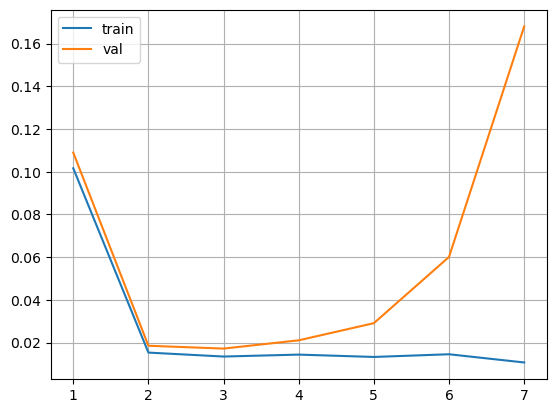

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate

df = pd.read_csv('quiz3_dataset-1.csv')
x = df[['x1','x2','x3']]
y = df['y']
x = np.array(x)
y = np.array(y)

x_train = x[0:300,:]
y_train = y[0:300]
x_test = x[300:,:]
y_test = y[300:]
model = LinearRegression()

D = 7
validation_error = np.empty(D)
training_error = np.empty(D)
for i in range(D):
    d = i+1
    t_x = PolynomialFeatures(d)
    t_train = t_x.fit_transform(x_train)

    cv_results = cross_validate(model, t_train, y_train, cv=10, return_train_score = True, scoring='r2')
    # Note: The parameter "scoring" above specifies the type of the score that will be returned (here r2 score)
    training_error[i] = 1-np.mean(cv_results['train_score'])
    validation_error[i] = 1-np.mean(cv_results['test_score'])

plt.plot([i+1 for i in range(D)],training_error)
plt.plot([i+1 for i in range(D)],validation_error)
plt.legend(['train','val'])
plt.grid(1)

In [51]:
# Take the number of non linear transformations based on best validation
d_best = np.argmin(validation_error) + 1
print(d_best)

# Transform the test and training dataset
poly_x = PolynomialFeatures(d_best)
t_train = poly_x.fit_transform(x_train)
t_test = poly_x.fit_transform(x_test)

# Fit the model to the training
model.fit(t_train, y_train)
print(t_test.shape, y_test.shape)

# Find the R2 value
print(model.score(t_test, y_test))


3
(100, 20) (100,)
0.9877518359188655


ValueError: continuous is not supported